In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [3]:
data_folder = '/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=43)

filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_06-54-23_M21_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_4/2026-04-28_19-57-43_M22_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260418_1/2026-04-28_18-35-32_M23_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/da

In [4]:
dropped_trials = 1

In [5]:
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 539
First trial end event found at index: 545
First trial end event found at index: 539
First trial end event found at index: 555
First trial end event found at index: 556
First trial end event found at index: 557
First trial end event found at index: 553
First trial end event found at index: 547
First trial end event found at index: 576
First trial end event found at index: 547
First trial end event found at index: 518
First trial end event found at index: 519
First trial end event found at index: 545
First trial end event found at index: 553
First trial end event found at index: 578
First trial end event found at index: 546
First trial end event found at index: 533
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 538
First trial end event found at index: 538
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at ind

In [6]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [10]:
import os

In [ ]:
def score_rate_player0_sessions(data_folder, json_filenames, time_unit="s"):
    """Return array (num_sessions,) of player 0 score per unit time.

    - Scores summed across all trial-end events
    - Time computed from number of timepoints (0.02 s per step)
    """

    score_rates = np.zeros(len(json_filenames))

    for idx, json_filename in enumerate(json_filenames):
        print(data_folder + os.sep + json_filename)

        _, trials_list = prepare_data.prepare_data(data_folder, json_filename)

        total_score = 0
        total_time_seconds = 0

        for trial_index in range(len(trials_list)):
            trial = extract_trial
            # accumulate time
            total_time_seconds += len(trial) * 0.02

            # get trial-end score
            trial_end = trial[trial["eventDescription"] == "trial end"]

            if len(trial_end) == 0:
                continue

            trial_end_row = trial_end.iloc[-1]

            total_score += trial_end_row[
                globals.PLAYER_SCORE_DICT[0]["score"]
            ]

        print(f"total time in seconds {total_time_seconds}")
        print(f"length of trial list and total score {len(trials_list),total_score}")
        # convert time unit
        if time_unit == "min":
            total_time = total_time_seconds / 60
        elif time_unit == "s":
            total_time = total_time_seconds
        else:
            raise ValueError("time_unit must be 's' or 'min'")

        if total_time == 0:
            score_rates[idx] = np.nan
        else:
            score_rates[idx] = total_score / total_time

    return score_rates

In [44]:
def score_rate_player0_sessions(
    data_folder,
    json_filenames,
    time_unit="s",
    max_decision_duration=None
):
    """Player 0 score per unit time.

    Time is counted only between slice onset and trigger activation.
    Scores are summed across trial-end events.
    """

    score_rates = np.zeros(len(json_filenames))

    for idx, json_filename in enumerate(json_filenames):
        print(data_folder + os.sep + json_filename)

        _, trials_list = prepare_data.prepare_data(data_folder, json_filename)

        total_score = 0
        total_time_seconds = 0

        for this_trial in trials_list:

            slice_onset_event = this_trial[
                this_trial["eventDescription"] == globals.SLICE_ONSET
            ]

            trigger_event = this_trial[
                this_trial["eventDescription"] == globals.SELECTED_TRIGGER_ACTIVATION
            ]

            trial_end = this_trial[
                this_trial["eventDescription"] == "trial end"
            ]

            if len(slice_onset_event) == 0:
                continue

            if len(trigger_event) == 0:
                continue

            if len(trial_end) == 0:
                continue

            slice_onset_idx = slice_onset_event.index[0]
            slice_onset_idx = int(slice_onset_idx - this_trial.index[0])

            trigger_idx = trigger_event.index[0]
            trigger_idx = int(trigger_idx - this_trial.index[0])

            decision_duration = (trigger_idx - slice_onset_idx) * 0.02

            if decision_duration < 0:
                continue

            if max_decision_duration is not None:
                if decision_duration > max_decision_duration:
                    continue

            trial_end_row = trial_end.iloc[-1]

            total_score += trial_end_row[
                globals.PLAYER_SCORE_DICT[0]["score"]
            ]

            total_time_seconds += decision_duration

        if time_unit == "min":
            total_time = total_time_seconds / 60
        elif time_unit == "s":
            total_time = total_time_seconds
        else:
            raise ValueError("time_unit must be 's' or 'min'")

        if total_time == 0:
            score_rates[idx] = np.nan
        else:
            score_rates[idx] = total_score / total_time

    return score_rates

In [55]:
score_rates = score_rate_player0_sessions(
    data_folder,
    solo_files,
    time_unit="min",
    max_decision_duration=5
)

/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
Loading complete.
Preprocessing complete.
/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
Loading complete.
Preprocessing complete.
/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
Loading complete.
Preprocessing complete.
/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_06-54-23_M21_Solo.json
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_0

In [46]:
score_rates

array([ 3.499009  , 20.78870205,  4.01547255, 15.97140065, 14.0224481 ,
       25.65242672,  8.78960683, 26.13054007, 26.96510398, 24.20270332,
       26.19498571, 24.05889042,  6.46073448, 22.62696887,  4.68400696,
       24.65262214, 16.53441349, 25.30938593, 12.42898398, 27.96500188,
       15.90524535, 27.385755  , 25.73529412, 26.5383928 , 25.37990178,
       24.88818352, 26.28919624, 25.3577741 , 27.5904611 ,  5.5567132 ,
        5.31336022, 25.75660968, 20.65100183, 29.5357406 ,  2.47115771,
       11.98656178, 25.57658396, 25.33159382,  5.09952817, 25.2495596 ,
        2.44100895, 25.93671826, 27.36697774])

In [56]:
score_rates

array([22.04528315, 21.93827715, 22.72428395, 18.14241111, 18.20407729,
       25.65242672, 18.75040976, 26.13054007, 26.96510398, 24.20270332,
       26.19498571, 24.05889042, 18.42186061, 22.70153628, 20.07183171,
       24.65262214, 23.07337333, 25.30938593, 19.83926263, 27.96500188,
       17.9247577 , 27.385755  , 25.73529412, 26.5383928 , 25.37990178,
       24.88818352, 26.28919624, 25.3577741 , 27.5904611 , 12.41245555,
       13.42517168, 25.75660968, 21.05045117, 29.5357406 , 15.33771554,
       12.07133444, 25.57658396, 25.33159382, 16.2690719 , 25.2495596 ,
       15.11715797, 25.93671826, 27.36697774])

### Parameter value extraction

In [47]:
import agent_analysis.functions.preprocessing as prep

In [57]:
_, step_penalties = prep.extract_step_penalties(data_folder, yaml_filename=None)

In [58]:
penalties = np.array(step_penalties)
score_rates = np.array(score_rates) 

In [59]:
low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

In [104]:
low_group = score_rates[penalties <= low_thresh]

mid_low_group = score_rates[
    (penalties > low_thresh) & (penalties <= mid_thresh)
]

mid_high_group = score_rates[
    (penalties > mid_thresh) & (penalties <= high_thresh)
]

high_group = score_rates[penalties > high_thresh]

In [105]:
data = [
    low_group,
    mid_low_group,
    mid_high_group,
    high_group
]

In [62]:
print(len(low_group), len(mid_low_group), len(mid_high_group), len(high_group))
print("Total:", sum(len(g) for g in data), "Expected:", len(score_rates))

11 11 10 11
Total: 43 Expected: 43


In [64]:
from scipy.stats import kruskal, mannwhitneyu

In [65]:
# overall test
stat, p = kruskal(low_group, mid_low_group, mid_high_group, high_group)
print("Kruskal-Wallis p =", p)

# pairwise tests
p_low_midlow = mannwhitneyu(low_group, mid_low_group).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_group, mid_high_group).pvalue
p_midhigh_high = mannwhitneyu(mid_high_group, high_group).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_group, mid_high_group).pvalue
p_midlow_high = mannwhitneyu(mid_low_group, high_group).pvalue
p_low_high = mannwhitneyu(low_group, high_group).pvalue

Kruskal-Wallis p = 5.7623930949716994e-05


In [67]:
print(p_low_midlow,p_midlow_midhigh,p_midhigh_high)

0.06597105309665711 0.05280751141611358 0.08448458362150606


In [68]:
print(p_low_midhigh,p_midlow_high,p_low_high)

0.00827421565071521 0.0012927447796956875 8.151536127743242e-05


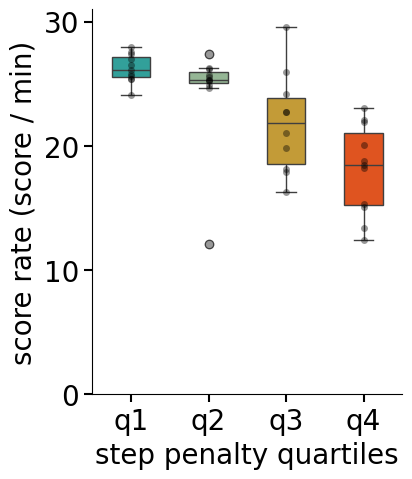

In [106]:
palette = ["lightseagreen", "darkseagreen", "goldenrod", "orangered"]

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)
plt.ylim([0, 31])
plt.yticks(np.arange(0, 31, 10), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

plt.ylabel("score rate (score / min)", fontsize=20)
plt.xlabel("step penalty quartiles", fontsize=20)

sns.despine(top=True, right=True)
plt.show()

In [71]:
from analysis import opponent_visibility

Get slice onset positions for each session for each trial

In [72]:
slice_onset_positions_dict = {}
for j, trial_list in enumerate(trial_lists):
    pos_list = []
    for i in range(len(trial_list)):
        if i == 0:
            continue
        slice_onset_positions = (opponent_visibility.get_player_position_slice_onset(player_id=0, trial=None, trial_list=trial_list, trial_index=i))
        pos_list.append(slice_onset_positions)
    slice_onset_positions_dict[j] = pos_list

Find the arena radius through the data

In [73]:
all_positions = np.array([
    pos for pos_list in slice_onset_positions_dict.values()
    for pos in pos_list
    if pos is not None
])

In [74]:
arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

In [75]:
arena_radius

np.float64(19.74449542008289)

In [111]:
centrality_dict = {}
mean_centrality_dict = {}
for j, pos_list in slice_onset_positions_dict.items():
    centrality_dict[j] = []
    for pos in pos_list:
        if pos is None:
            centrality_dict[j].append(np.nan)
            continue
        dist = np.linalg.norm(pos)
        centrality = 1 - (dist / arena_radius) if arena_radius > 0 else 1.0
        centrality_dict[j].append(centrality)
    mean_centrality_dict[j] = np.nanmean(centrality_dict[j])

In [112]:
# collect average centrality for each session, sorted by step penalty
mean_centrality_list = []
std_centrality_list = []
sem_centrality_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, mean_centrality_dict.keys()), key=lambda x: x[0]):
    #if session_id == 31:
        #continue
    
    values = np.array(centrality_dict[session_id], dtype=float)
    mean_centrality_list.append(np.mean(values))
    std_centrality_list.append(np.std(values))
    sem_centrality_list.append(np.nanstd(values) / np.sqrt(np.sum(~np.isnan(values))))
    sorted_penalties.append(penalty)

In [113]:
score_rates = np.array(score_rates)

mean_centrality_array = np.array(mean_centrality_list)


In [114]:
low_c = np.percentile(mean_centrality_array, 25)
mid_c = np.percentile(mean_centrality_array, 50)
high_c = np.percentile(mean_centrality_array, 75)

In [115]:
low_group = score_rates[mean_centrality_array <= low_c]

mid_low_group = score_rates[
    (mean_centrality_array > low_c) & (mean_centrality_array <= mid_c)
]

mid_high_group = score_rates[
    (mean_centrality_array > mid_c) & (mean_centrality_array <= high_c)
]

high_group = score_rates[mean_centrality_array > high_c]

In [116]:
# overall test
stat, p = kruskal(low_group, mid_low_group, mid_high_group, high_group)
print("Kruskal-Wallis p =", p)

# pairwise tests
p_low_midlow = mannwhitneyu(low_group, mid_low_group).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_group, mid_high_group).pvalue
p_midhigh_high = mannwhitneyu(mid_high_group, high_group).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_group, mid_high_group).pvalue
p_midlow_high = mannwhitneyu(mid_low_group, high_group).pvalue
p_low_high = mannwhitneyu(low_group, high_group).pvalue

Kruskal-Wallis p = 0.41687376629410655


In [117]:
print(p_low_midlow,p_midlow_midhigh,p_midhigh_high)

0.18908180596451618 0.34178646181502725 0.915878445665947


In [118]:
print(p_low_midhigh,p_midlow_high,p_low_high)

0.34178646181502725 0.430708328947102 0.26429152373398135


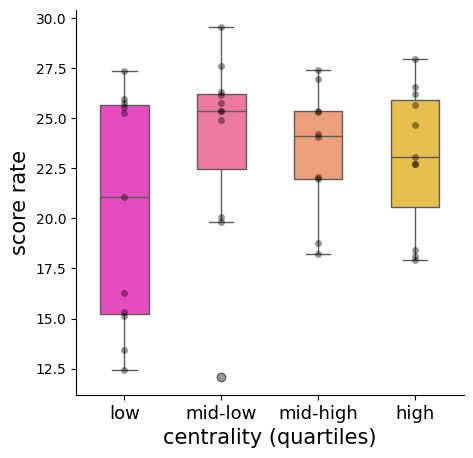

In [119]:
data = [low_group, mid_low_group, mid_high_group, high_group]

palette = sns.color_palette("spring", 4)

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, palette=palette, width=0.5)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks(
    [0, 1, 2, 3],
    ['low', 'mid-low', 'mid-high', 'high'],
    fontsize=13
)

plt.xlabel("centrality (quartiles)", fontsize=15)
plt.ylabel("score rate", fontsize=15)

sns.despine(top=True, right=True)

plt.show()

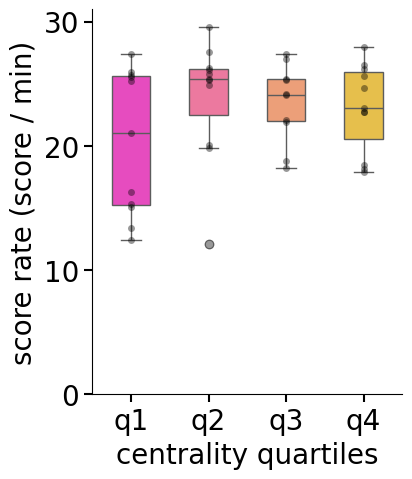

In [120]:
palette = ["lightseagreen", "darkseagreen", "goldenrod", "orangered"]

palette = sns.color_palette("spring", 4)

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)
plt.ylim([0, 31])
plt.yticks(np.arange(0, 31, 10), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

plt.ylabel("score rate (score / min)", fontsize=20)
plt.xlabel("centrality quartiles", fontsize=20)

sns.despine(top=True, right=True)
plt.show()